### **In Class Linear Regression Examples and Practice**

## **PAIR ASSIGNMENT**

Please work in pairs for this exercise. Pair up with the person next to you. If you find that there isn't anyone sitting next to you or if you're unable to form a pair, please raise your hand, and I will assist in pairing you with someone.


### **Task 0: Please assign your full name and your partner's full name to the variables below, respectively.**


Example:

```
your_name = 'Taylor Swift'
your_partner_name = 'Travis Kelce'
```


### **TASK 0: Please assign your full name and your partner's full name to the variables below, respectively.**


In [ ]:
# Assign your and your partner's names here.  If you find that there isn't anyone sitting next to you or if you're unable to form a pair, please raise your hand.
# If, in the end, we are unable to find a partner for you, please assign the word "self" to the `your_partner_name` variable.
your_name = 'Jonathan Cruz'
your_partner_name = ''

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.impute import SimpleImputer


# **PART 1**



#### **Simple Linear Regression**

* Using the `USA_Housing` dataset, we will look at linear relationships.

### **TASK 1**

* Load the `USA_Housing.csv` into a dataframe.
* Display the first few rows to view the dataset.

In [2]:
# Write your code here
df = pd.read_csv("USA_Housing.csv")
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


#### **TASK 2: We will need to drop the categorical column and only keep numeric columns in our dataset. For this, let's drop the "Address" column.**

Note: Once we dive into feature engineering, we will learn how to encode categorical columns so that we can include them in our regression analysis.

In [3]:
# Code here
df_numeric = df.drop("Address", axis=1)
df_numeric.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05


In [4]:
df_numeric.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05


#### **TASK 3: Scatter Plot Discussion with your Partner**

* To determine which independent variable has a strong linear relationship with the house price, we should first plot scatterplots for each independent variable against the house price. Then, by visually assessing these plots, we can identify which variable seems to exhibit the strongest linear trend with the house price.

* The more closely the points resemble a straight line, the stronger the linear relationship.

* **TODO:** Run the code cell below and observe the output. Discuss with your exercise partner what the following plots show. Write your findings in a few sentences below.

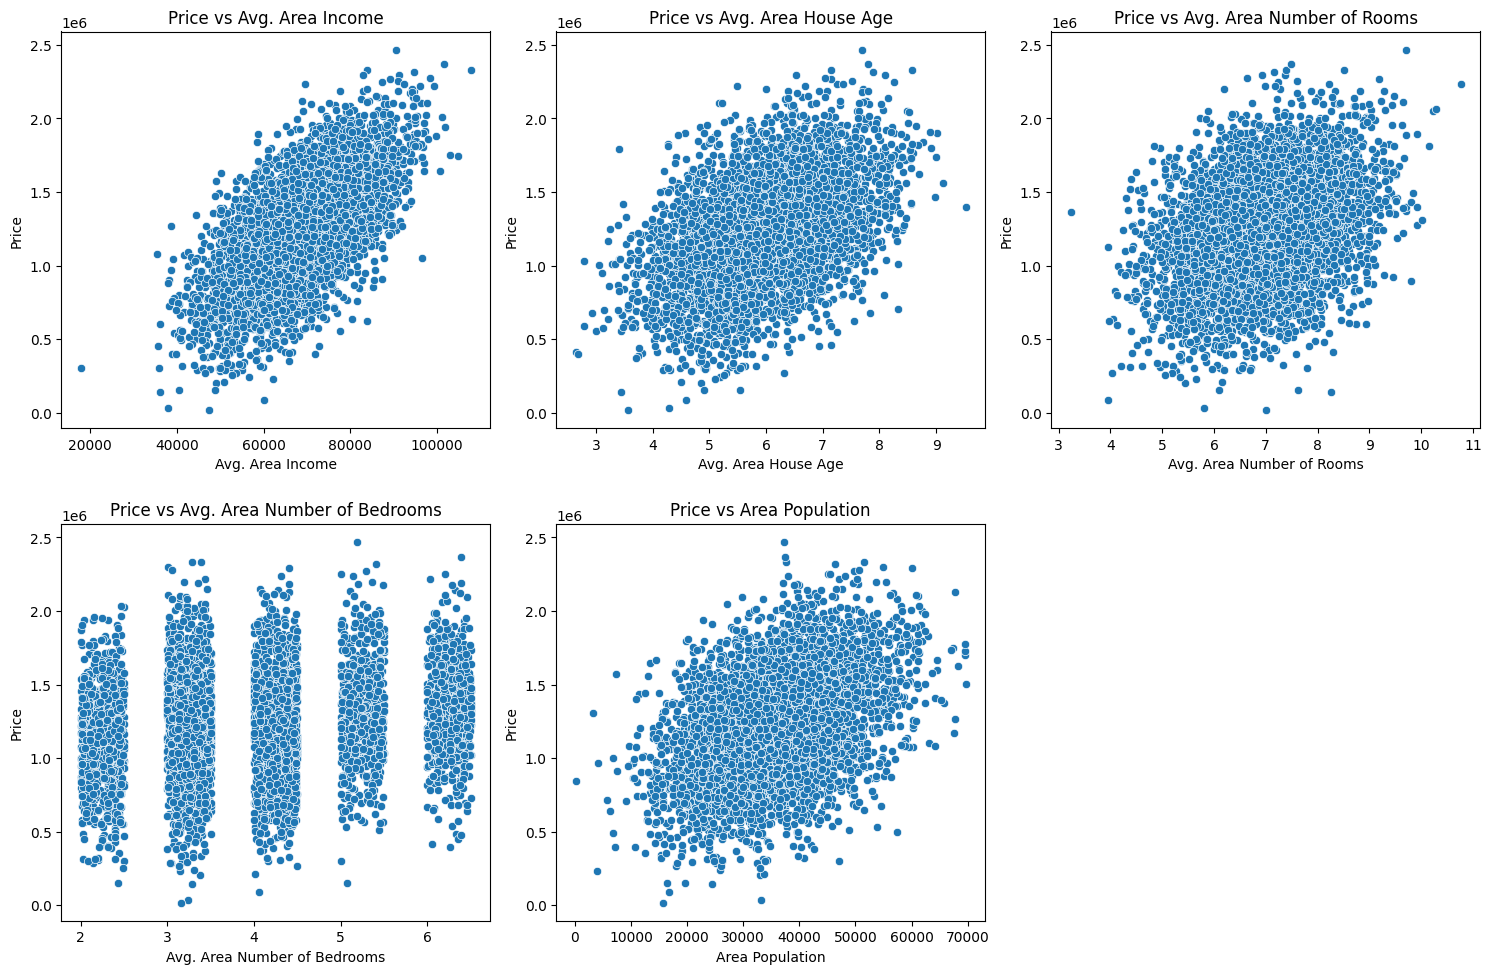

In [5]:
import seaborn as sns

plt.figure(figsize=(15, 10))

for i, column in enumerate(df_numeric.columns[:-1], 1):  # Assuming the last column is the dependent variable (house price)
    #complete the plot
    plt.subplot(2,3,i)
    sns.scatterplot(data=df_numeric, x = column, y = 'Price')
    plt.title(f'Price vs {column}')

plt.tight_layout()
plt.show()

**WRITE YOUR ANSWER HERE:**
In these plots we can see that Price has the strongest positive linear relationship with avg area income and has the weakest linear relationship with avg area number of bedrooms

#### **The code below calculates the Pearson Correlation Coefficients for each independent variable against the dependent variable (y) which is the house price.**

In [6]:
# Compute the correlation coefficients for each independent variable against the house price
correlations = df_numeric.corr()['Price'].drop('Price') # corr() calculates pairwise correlation of columns.

# Take the absolute value of correlations. The reason to take the absolute value is to focus on the
# strength of the relationship, regardless of its direction (positive or negative).
# Sorting the values in descending order will allow the variable with the strongest absolute linear
# relationship with 'Price' to comes first.
sorted_correlations = correlations.abs().sort_values(ascending=True)


print(f'Independent variables in the dataset sorted by the strength of their linear relationship \n with the "Price" column, irrespective of whether that relationship is positive or negative.\n {sorted_correlations}')

Independent variables in the dataset sorted by the strength of their linear relationship 
 with the "Price" column, irrespective of whether that relationship is positive or negative.
 Avg. Area Number of Bedrooms    0.171071
Avg. Area Number of Rooms       0.335664
Area Population                 0.408556
Avg. Area House Age             0.452543
Avg. Area Income                0.639734
Name: Price, dtype: float64


#### **Let's visualize these correlations**

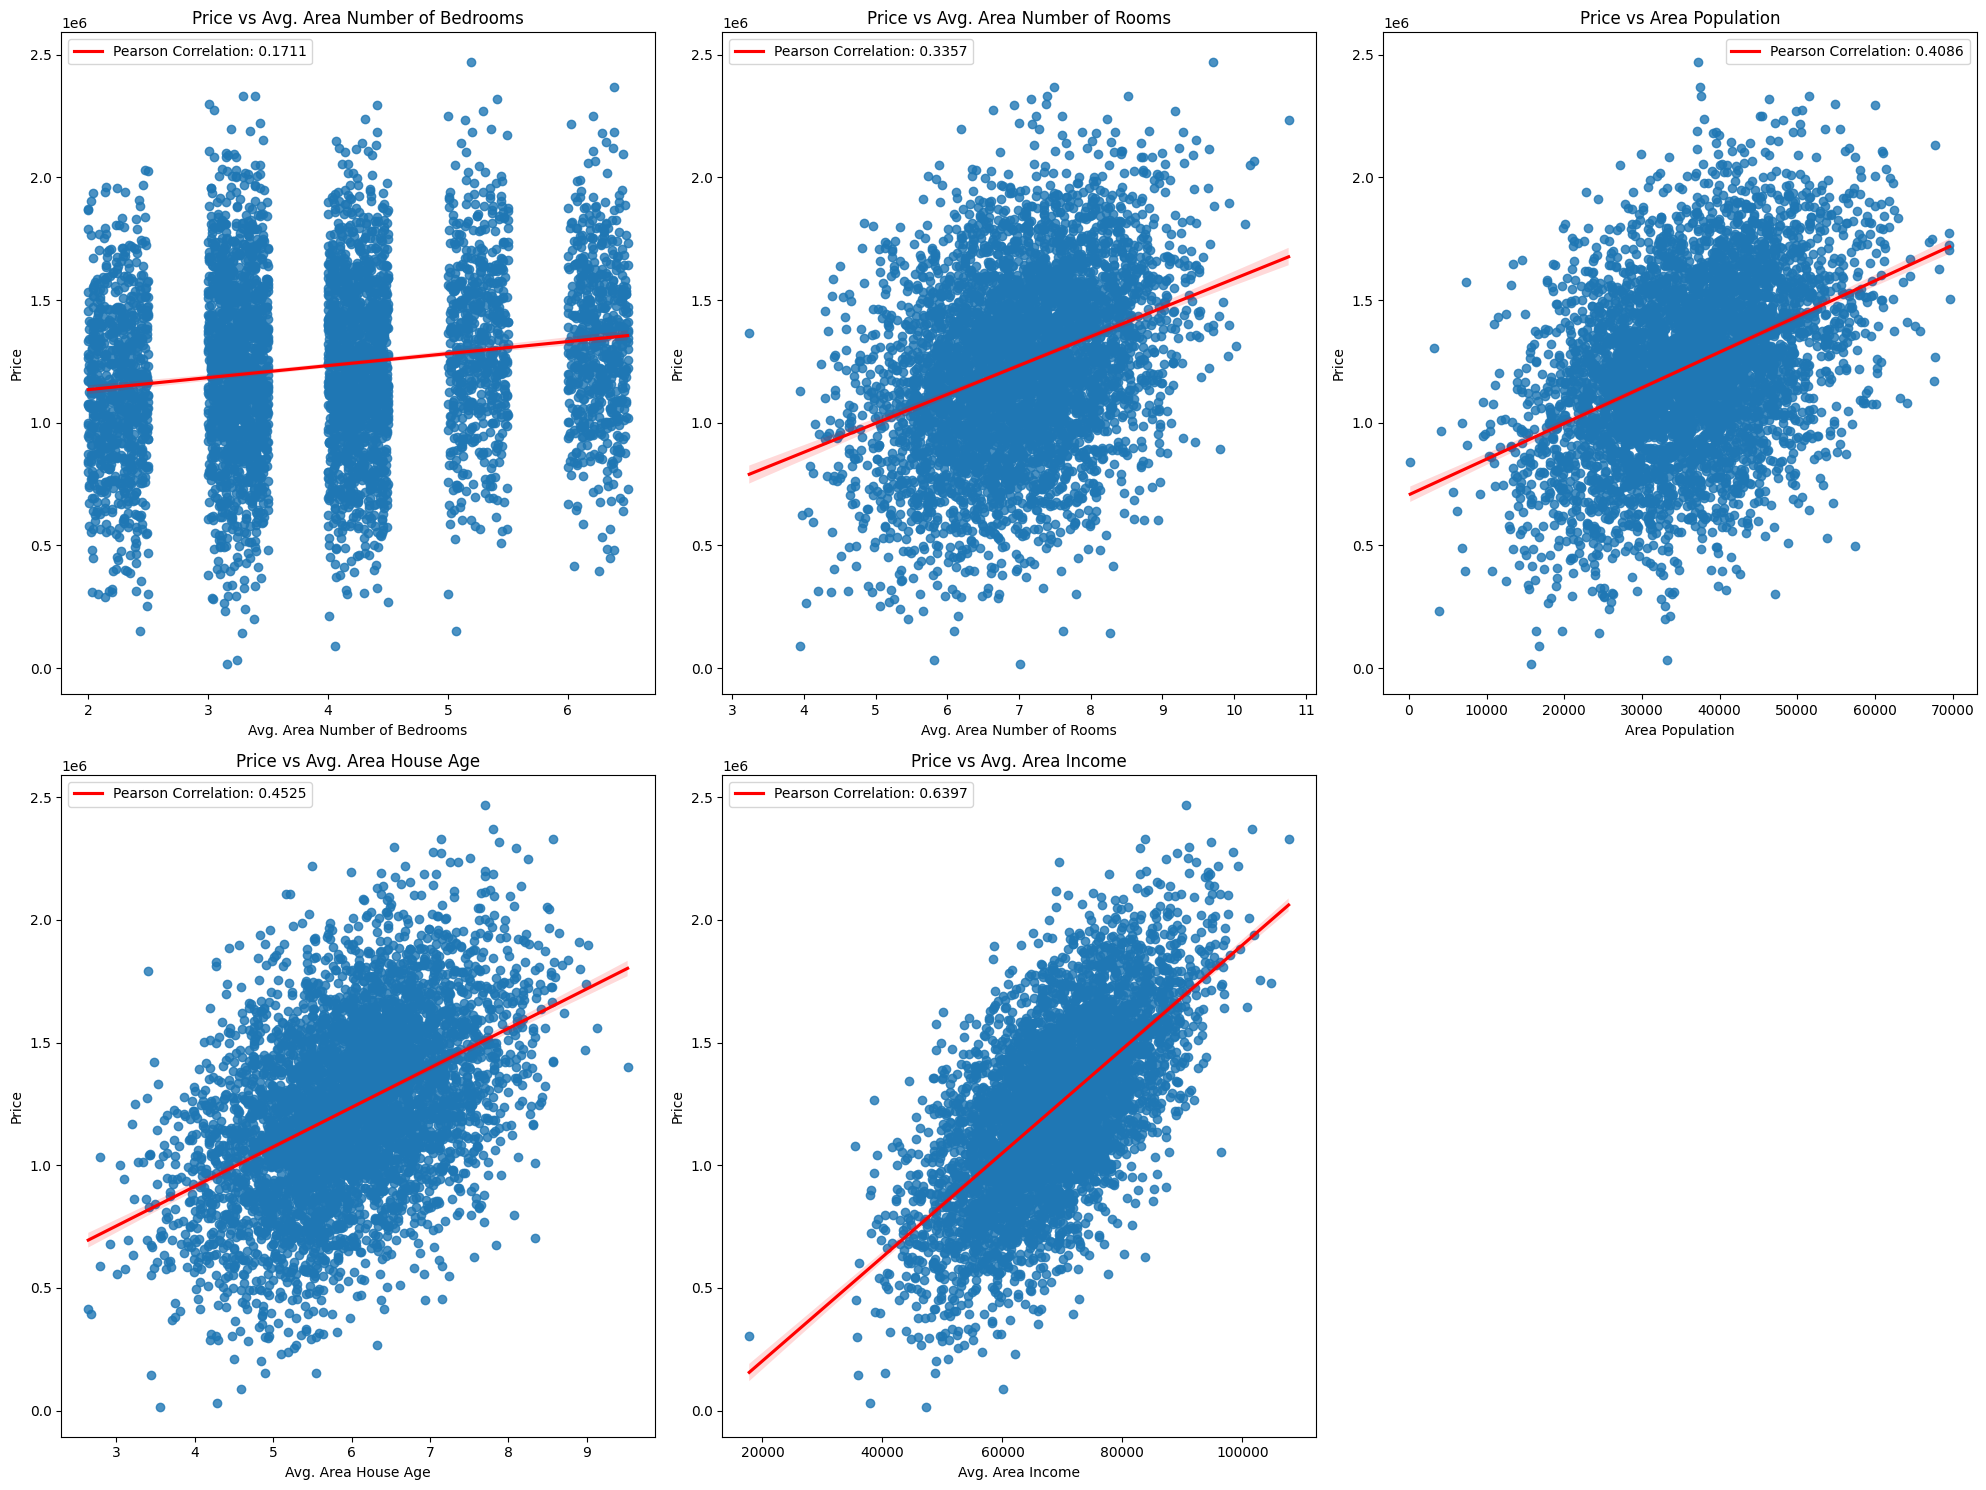

In [7]:
plt.figure(figsize=(20, 15))

for i, column in enumerate(sorted_correlations.index, 1):
    plt.subplot(2, 3, i)
    sns.regplot(data=df_numeric, x=column, y='Price', line_kws={"color": "red", "label": f"Pearson Correlation: {sorted_correlations[column]:.4f}"})
    plt.title(f"Price vs {column}")
    plt.legend()

plt.tight_layout()
plt.show()

### **TASK 4:**
* Observe the results of the plots, and discuss the output with your partner exercise and make sure you both udnerstand what the Pearson Correlation is telling us here. What is/are the feature(s) that is considerably linearly correlated to the housing price?

**WRITE YOUR ANSWER HERE:**
The feature that is considerably linearly correlated to the housing price is avg area income because it looks like it fits the line the best out of all of them.

# **PART 2**

#### **Linear Regression with `scikit-learn`**


In this part of the exercise, you will start using scikit-learn library to implement and train a Linear Regression model using the `cancer_reg.csv` dataset which contains data that is aggregated from a number of sources including the American Community Survey (census.gov), clinicaltrials.gov, and cancer.gov.

Here is an explanation of the features in this dataset:



```
Data Dictionary
TARGET_deathRate: Dependent variable. Mean per capita (100,000) cancer mortalities(a)

avgAnnCount: Mean number of reported cases of cancer diagnosed annually(a)

avgDeathsPerYear: Mean number of reported mortalities due to cancer(a)

incidenceRate: Mean per capita (100,000) cancer diagoses(a)

medianIncome: Median income per county (b)

popEst2015: Population of county (b)

povertyPercent: Percent of populace in poverty (b)

studyPerCap: Per capita number of cancer-related clinical trials per county (a)

binnedInc: Median income per capita binned by decile (b)

MedianAge: Median age of county residents (b)

MedianAgeMale: Median age of male county residents (b)

MedianAgeFemale: Median age of female county residents (b)

Geography: County name (b)

AvgHouseholdSize: Mean household size of county (b)

PercentMarried: Percent of county residents who are married (b)

PctNoHS18_24: Percent of county residents ages 18-24 highest education attained: less than high school (b)

PctHS18_24: Percent of county residents ages 18-24 highest education attained: high school diploma (b)

PctSomeCol18_24: Percent of county residents ages 18-24 highest education attained: some college (b)

PctBachDeg18_24: Percent of county residents ages 18-24 highest education attained: bachelor's degree (b)

PctHS25_Over: Percent of county residents ages 25 and over highest education attained: high school diploma (b)

PctBachDeg25_Over: Percent of county residents ages 25 and over highest education attained: bachelor's degree (b)

PctEmployed16_Over: Percent of county residents ages 16 and over employed (b)

PctUnemployed16_Over: Percent of county residents ages 16 and over unemployed (b)

PctPrivateCoverage: Percent of county residents with private health coverage (b)

PctPrivateCoverageAlone: Percent of county residents with private health coverage alone (no public assistance) (b)

PctEmpPrivCoverage: Percent of county residents with employee-provided private health coverage (b)

PctPublicCoverage: Percent of county residents with government-provided health coverage (b)

PctPubliceCoverageAlone: Percent of county residents with government-provided health coverage alone (b)

PctWhite: Percent of county residents who identify as White (b)

PctBlack: Percent of county residents who identify as Black (b)

PctAsian: Percent of county residents who identify as Asian (b)

PctOtherRace: Percent of county residents who identify in a category which is not White, Black, or Asian (b)

PctMarriedHouseholds: Percent of married households (b)

BirthRate: Number of live births relative to number of women in county (b)

(a): years 2010-2016

(b): 2013 Census Estimates
```



### **TASK 5: Load the dataset with the parameter and its value `encoding=latin1` to handle non-UTF-8 characters.**

In [8]:
# Write your code here
df = pd.read_csv("cancer_reg.csv", encoding="latin1")
df.head()

,avgAnnCount,avgDeathsPerYear,TARGET_deathRate,incidenceRate,medIncome,popEst2015,povertyPercent,studyPerCap,binnedInc,MedianAge,...,PctPrivateCoverageAlone,PctEmpPrivCoverage,PctPublicCoverage,PctPublicCoverageAlone,PctWhite,PctBlack,PctAsian,PctOtherRace,PctMarriedHouseholds,BirthRate
0,1397.0,469,164.9,489.8,61898,260131,11.2,499.748204,"(61494.5, 125635]",39.3,...,NaN,41.6,32.9,14.0,81.780529,2.594728,4.821857,1.843479,52.856076,6.118831
1,173.0,70,161.3,411.6,48127,43269,18.6,23.111234,"(48021.6, 51046.4]",33.0,...,53.8,43.6,31.1,15.3,89.228509,0.969102,2.246233,3.741352,45.372500,4.333096
2,102.0,50,174.7,349.7,49348,21026,14.6,47.560164,"(48021.6, 51046.4]",45.0,...,43.5,34.9,42.1,21.1,90.922190,0.739673,0.465898,2.747358,54.444868,3.729488
3,427.0,202,194.8,430.4,44243,75882,17.1,342.637253,"(42724.4, 45201]",42.8,...,40.3,35.0,45.3,25.0,91.744686,0.782626,1.161359,1.362643,51.021514,4.603841
4,57.0,26,144.4,350.1,49955,10321,12.5,0.000000,"(48021.6, 51046.4]",48.3,...,43.9,35.1,44.0,22.7,94.104024,0.270192,0.665830,0.492135,54.027460,6.796657


### **TASK 6: Prepare the data by selecting numeric columns and dropping the target variable (`TARGET_deathRate`).**

In [ ]:
df_numeric = df.select_dtypes(include=['number'])
X = df_numeric.drop("TARGET_deathRate", axis=1)
y = df_numeric["TARGET_deathRate"]


### **TASK 7: Split the data into training and testing sets**

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### **TASK 8: Impute missing values with the mean of each column for `X_train` and X_test`.**

In [14]:
imputer = SimpleImputer(strategy="mean")
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)


### **TASK 9: Initialize and train (remember training is fitting) the linear regression model using Scikit-learn LinearRegression() estimator.**

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### **TASK 10: Make predictions on the test set.**

In [16]:
y_pred = model.predict(X_test)

### **OPTIONAL TASK: Calculate performance metrics (i.e. mean_squared_error, mean_absolute_error, corrcoef (pearson correlation))**

In [17]:
#write your code here
mse = mean_squared_error( ...)
mae = mean_absolute_error(...)
pearson_corr = np.corrcoef(...)[0, 1]


# Print the performance metrics
print(f"Mean Squared Error (MSE): {mse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Pearson Correlation Coefficient: {pearson_corr}")

TypeError: missing a required argument: 'y_pred'

#### **EXTRA EXAMPLE: Linear Regression with NumPy: Dog Age and Vet Visit Count**

Let's study the relationship between the age of a dog and the number of veterinary visits it had.

In [18]:
# Random ages for 10 dogs between 1 and 15 years
np.random.seed(42)  # for reproducibility
dog_ages = np.sort(np.random.randint(1, 16, 10)) # Returns random integers from the “discrete uniform” distribution

* Let's assume older dogs tend to have more visits, but with some random noise.

In [19]:
# using np.maximum to ensure values are not below 0
vet_visits = np.maximum(dog_ages + np.random.randn(10) * 2, 0) # Generates random numbers from the standard normal distribution (mean = 0 and variance = 1).

* Computing coefficients for linear regression using numpy's polyfit function. `polyfit` fits a polynomial of a specified degree to a set of data points using a least-squares approach.

In [20]:
slope, intercept = np.polyfit(dog_ages, vet_visits, 1)

In [21]:
# Predicting the veterinary visits using the computed slope and intercept
predicted_visits_np = slope * dog_ages + intercept

#### **Let's visualize our simple regression model**

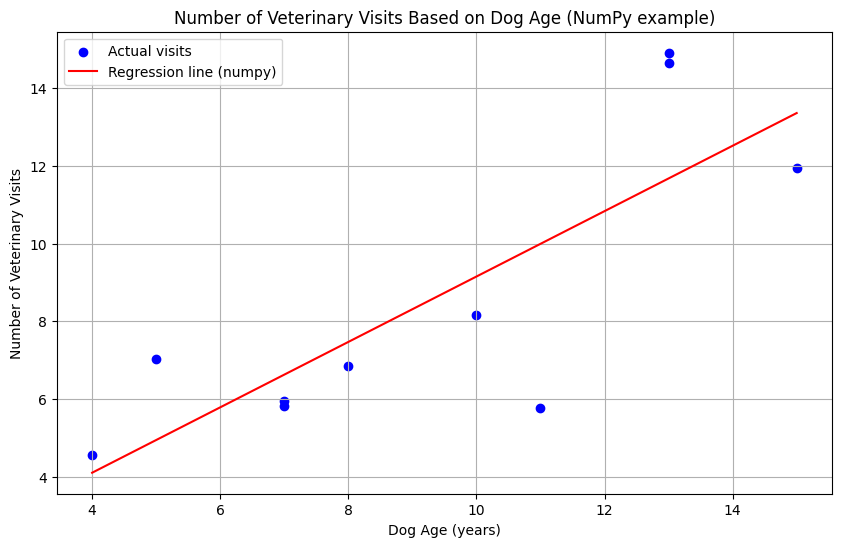

In [22]:
plt.figure(figsize=(10, 6))
plt.scatter(dog_ages, vet_visits, color='blue', label='Actual visits')
plt.plot(dog_ages, predicted_visits_np, color='red', label='Regression line (numpy)')
plt.title('Number of Veterinary Visits Based on Dog Age (NumPy example)')
plt.xlabel('Dog Age (years)')
plt.ylabel('Number of Veterinary Visits')
plt.grid(True)
plt.legend()
plt.savefig('dogvisits.png')
plt.show()

* The blue dots represent the actual number of veterinary visits for each dog based on its age.
* The red line is the regression line, which represents the predicted number of veterinary visits based on the age of the dog using our linear regression model.

#### **Linear Correlation Visuals**

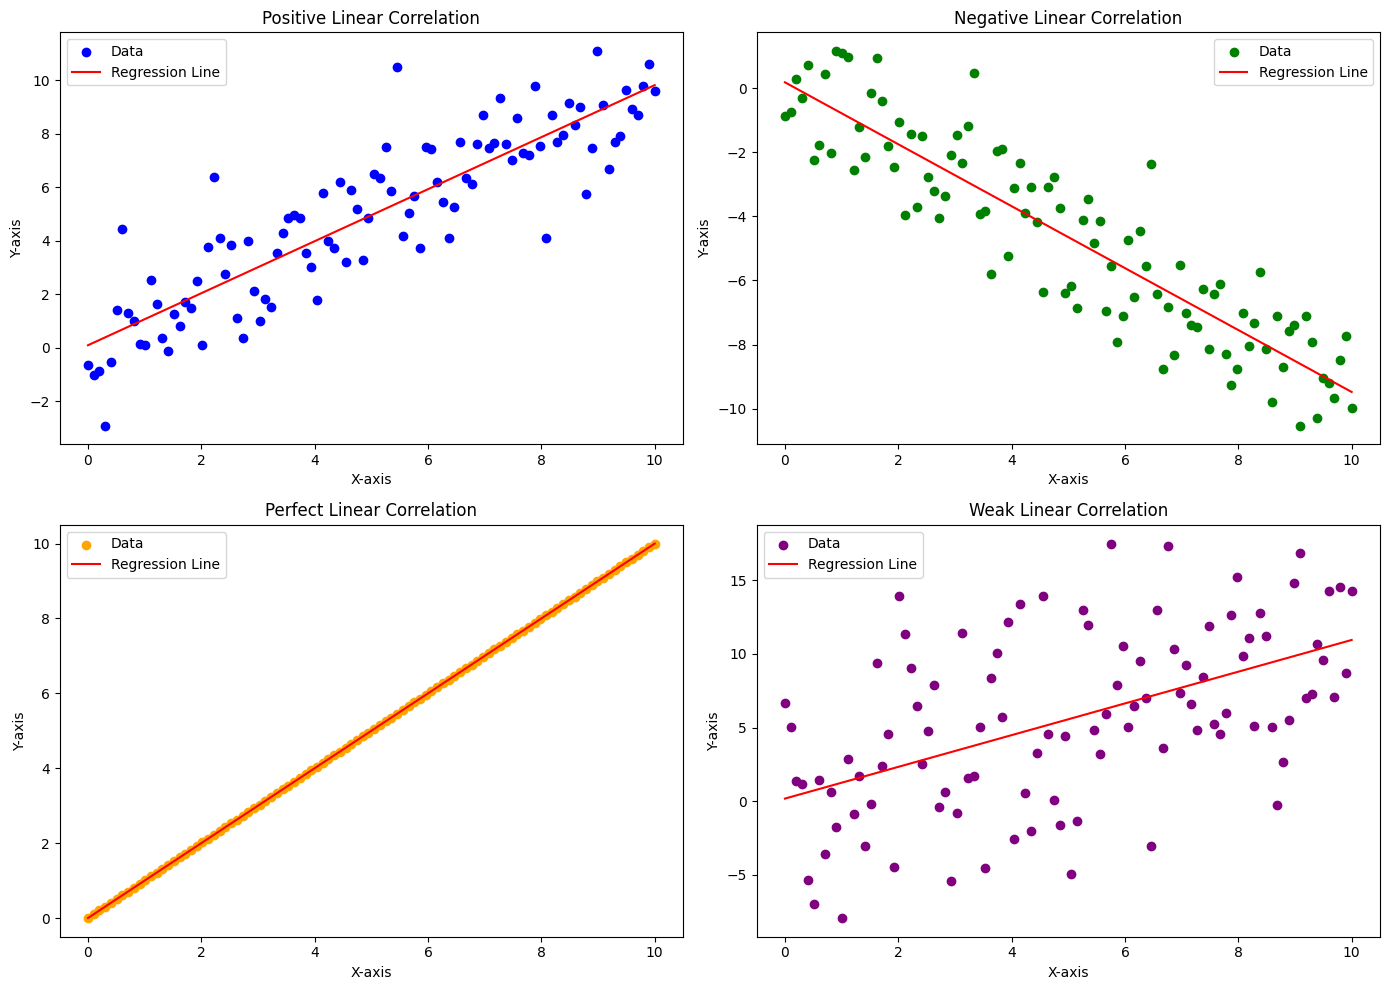

In [23]:
# Computing the regression lines for each dataset using numpy's polyfit

x = np.linspace(0, 10, 100)
y_positive = x + (np.random.randn(100) * 1.5)
y_negative = -x + (np.random.randn(100) * 1.5)
y_perfect = x
y_weak = x + (np.random.randn(100) * 5)



# Positive linear correlation
slope_positive, intercept_positive = np.polyfit(x, y_positive, 1)
regression_positive = slope_positive * x + intercept_positive

# Negative linear correlation
slope_negative, intercept_negative = np.polyfit(x, y_negative, 1)
regression_negative = slope_negative * x + intercept_negative

# Perfect linear correlation (no need to compute as it's just y_perfect)
regression_perfect = y_perfect

# Weak linear correlation
slope_weak, intercept_weak = np.polyfit(x, y_weak, 1)
regression_weak = slope_weak * x + intercept_weak

# Plotting the data with regression lines
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].scatter(x, y_positive, color='blue', label='Data')
axes[0, 0].plot(x, regression_positive, color='red', label='Regression Line')
axes[0, 0].set_title('Positive Linear Correlation')
axes[0, 0].set_xlabel('X-axis')
axes[0, 0].set_ylabel('Y-axis')
axes[0, 0].legend()

axes[0, 1].scatter(x, y_negative, color='green', label='Data')
axes[0, 1].plot(x, regression_negative, color='red', label='Regression Line')
axes[0, 1].set_title('Negative Linear Correlation')
axes[0, 1].set_xlabel('X-axis')
axes[0, 1].set_ylabel('Y-axis')
axes[0, 1].legend()

axes[1, 0].scatter(x, y_perfect, color='orange', label='Data')
axes[1, 0].plot(x, regression_perfect, color='red', label='Regression Line')
axes[1, 0].set_title('Perfect Linear Correlation')
axes[1, 0].set_xlabel('X-axis')
axes[1, 0].set_ylabel('Y-axis')
axes[1, 0].legend()

axes[1, 1].scatter(x, y_weak, color='purple', label='Data')
axes[1, 1].plot(x, regression_weak, color='red', label='Regression Line')
axes[1, 1].set_title('Weak Linear Correlation')
axes[1, 1].set_xlabel('X-axis')
axes[1, 1].set_ylabel('Y-axis')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('linear-correlations.png')
plt.show()